<a href="https://colab.research.google.com/github/Tamiim-Iqbal/Simulation-and-Modeling/blob/main/00.%20Project/Weather_Temperature_Simulation_%26_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Install and import libraries

In [ ]:
# Install packages

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime, timedelta

sns.set(style="whitegrid")
np.random.seed(42)


### 2. Generate random daily temperature data (matrix-style)

In [ ]:

# Parameters
n_years = 2
year_start = 2023
cities = ['Dhaka', 'Chattogram', 'Rangpur']        # three example cities
n_cities = len(cities)

# Create date range for 2 years daily data
start_date = datetime(year_start, 1, 1)
end_date = datetime(year_start + n_years, 1, 1)
dates = pd.date_range(start=start_date, end=end_date - pd.Timedelta(days=1), freq='D')
n_days = len(dates)

# Seasonal model + city-specific biases
# base_temp_by_city: average annual baseline temperature
base_temp_by_city = np.array([25.0, 20.0, 15.0])   # Dhaka warmer, Rangpur cooler
seasonal_amplitude = np.array([8.0, 6.0, 10.0])    # amplitude of seasonal swing
noise_sd_by_city = np.array([2.5, 2.0, 3.0])       # day-to-day noise

# Create day-of-year angle for sinusoid (0..2pi)   # summer & winter
day_of_year = np.array([d.timetuple().tm_yday for d in dates])
angles = 2 * np.pi * (day_of_year - 1) / 365.0

# Build temperature matrix: shape (n_days, n_cities)
temps = np.zeros((n_days, n_cities))
for j in range(n_cities):
    seasonal = seasonal_amplitude[j] * np.sin(angles - np.pi/2)  # shift so mid-year is warmest
    trend = 0.0  # optional trend per city (set non-zero to simulate warming)
    temps[:, j] = base_temp_by_city[j] + seasonal + trend + np.random.normal(0, noise_sd_by_city[j], n_days)

# Put into DataFrame (long format)
df = pd.DataFrame({
    'date': np.repeat(dates, n_cities),
    'city': np.tile(cities, n_days),
    'temp_c': temps.flatten()
})
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.dayofyear
df.head()


,date,city,temp_c,year,month,day
0,2023-01-01,Dhaka,18.241785,2023,1,1
1,2023-01-01,Chattogram,12.043254,2023,1,1
2,2023-01-01,Rangpur,4.372930,2023,1,1
3,2023-01-02,Dhaka,16.655525,2023,1,2
4,2023-01-02,Chattogram,14.817394,2023,1,2


### 3. Matrix operations (mean, reshape, slicing)

In [ ]:

# Temps is a matrix (numpy array).
print("temps shape (days, cities):", temps.shape)

# Column-wise means (mean annual temp per city)
mean_by_city = temps.mean(axis=0)
print("Mean annual temps by city:", dict(zip(cities, mean_by_city.round(2))))

# Row-wise mean (daily mean across cities)
daily_mean = temps.mean(axis=1)
#print("Daily mean temperature:", daily_mean.round(2))

# Reshape day-of-year x city (useful for heatmap: months x daybins)
# Example: compute monthly average matrix (12 months x cities)
monthly_avg = df.groupby(['month', 'city'])['temp_c'].mean().unstack()
print("\nMonthly average:")
print(monthly_avg)

# slicing: temps for first 7 days for Dhaka
dhaka_first_week = temps[:7, 0]   # first column = Dhaka
print("\nDhaka first week temps:", dhaka_first_week.round(2))


temps shape (days, cities): (731, 3)
Mean annual temps by city: {'Dhaka': np.float64(24.95), 'Chattogram': np.float64(20.2), 'Rangpur': np.float64(15.04)}

Monthly average:
city   Chattogram      Dhaka    Rangpur
month                                  
1       14.415204  17.291206   5.599340
2       16.024840  19.370089   8.424752
3       18.441801  22.491777  12.146722
4       21.406624  26.731643  17.096135
5       24.443026  30.289969  21.743920
6       26.263059  32.505369  24.894462
7       25.761669  32.789949  24.700778
8       24.404313  30.693638  22.334524
9       21.106808  27.237438  17.786503
10      18.988697  22.979956  12.636682
11      16.170059  19.697107   7.677498
12      14.722684  17.132688   5.184319

Dhaka first week temps: [18.24 16.66 18.62 20.82 16.43 16.44 20.99]


### 4. Line plot: Daily temperature time series for one city

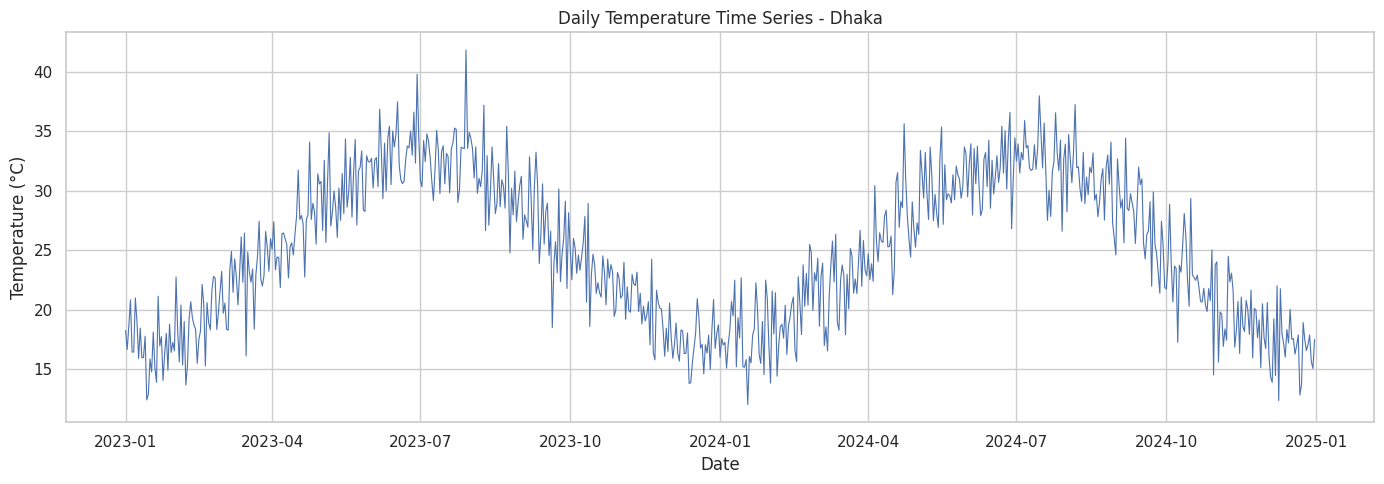

In [ ]:
plt.figure(figsize=(14,5))
city_to_plot = 'Dhaka'
sub = df[df['city'] == city_to_plot]
plt.plot(sub['date'], sub['temp_c'], lw=0.8)
plt.title(f'Daily Temperature Time Series - {city_to_plot}')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.tight_layout()
plt.show()


### 5. Bar plot: monthly average temperatures (grouped by city)

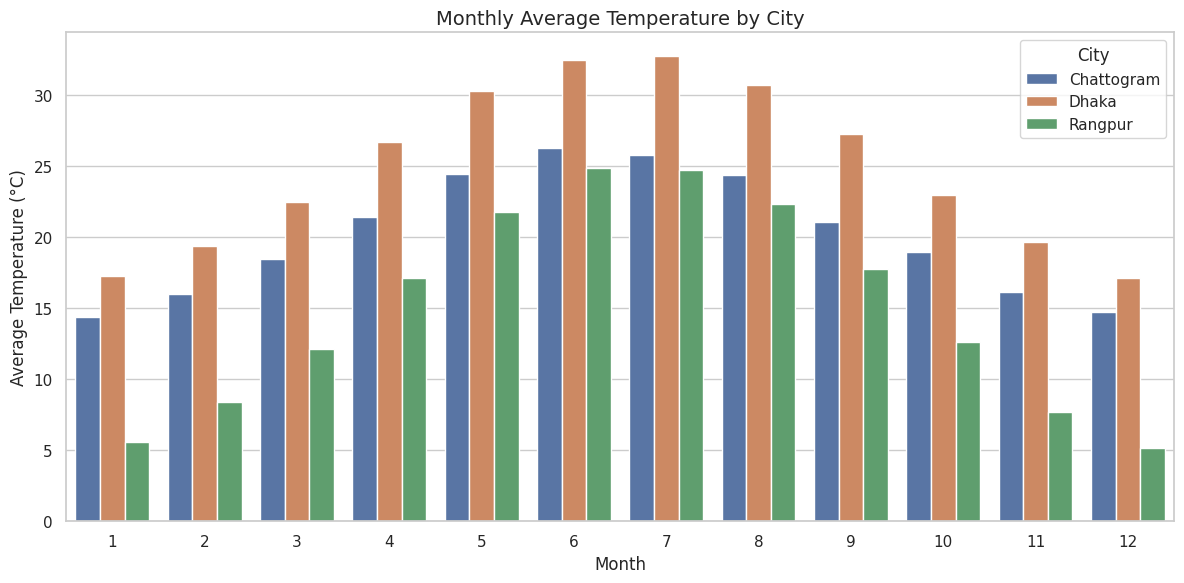

In [ ]:

plt.figure(figsize=(12,6))

# Reshape monthly_avg from wide to long format
monthly_avg_long = monthly_avg.reset_index().melt(id_vars='month', var_name='city', value_name='temp_c')

sns.barplot(
    data=monthly_avg_long,
    x='month',
    y='temp_c',
    hue='city',
)

plt.title('Monthly Average Temperature by City', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Temperature (°C)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='City')
plt.tight_layout()
plt.show()

### 6. Scatter plot: temp vs day-of-year

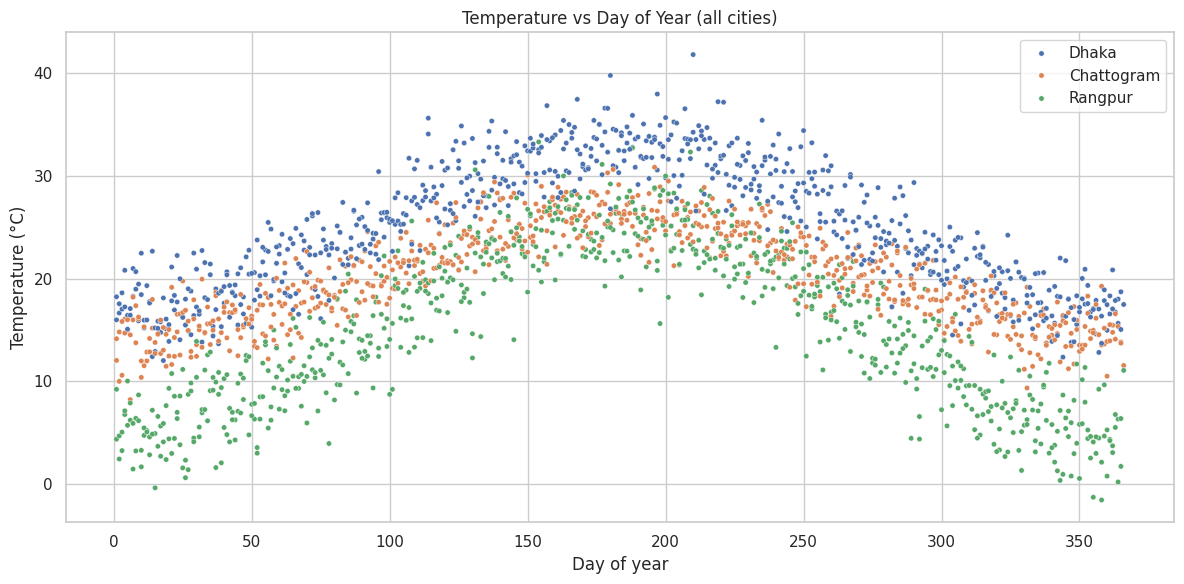

In [ ]:

plt.figure(figsize=(12,6))
sns.scatterplot(data=df, x='day', y='temp_c', hue='city', s=15, alpha=1)
plt.title('Temperature vs Day of Year (all cities)')
plt.xlabel('Day of year')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()


### 7. Heatmap: monthly-day (day bins) × city

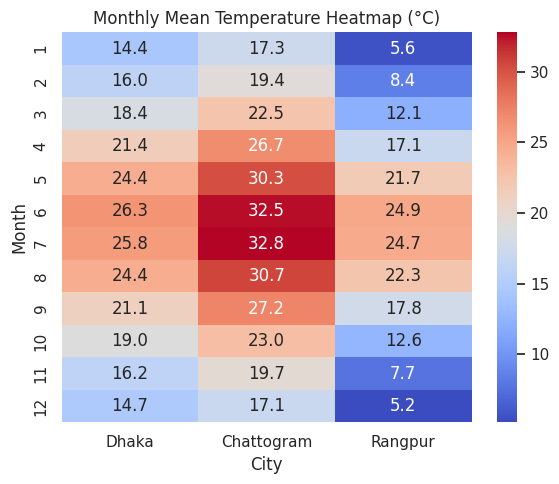

In [ ]:
# Build a matrix: month (rows) x city (columns) with monthly mean temperatures
monthly_matrix = monthly_avg.values  # shape (12, n_cities)
plt.figure(figsize=(6,5))
sns.heatmap(monthly_matrix, annot=True, fmt=".1f", yticklabels=range(1,13), xticklabels=cities, cmap='coolwarm')
plt.title('Monthly Mean Temperature Heatmap (°C)')
plt.xlabel('City')
plt.ylabel('Month')
plt.tight_layout()
plt.show()


### 8. One-sample t-test: is Dhaka's mean temperature equal to 22°C?

In [ ]:

# Dhaka temperature values
dhaka_temps = df[df['city']=='Dhaka']['temp_c'].values

# H0: mean = 22.0
test_mean = 22.0
tstat, pval = stats.ttest_1samp(dhaka_temps, test_mean)

print(f"One-sample t-test (Dhaka mean == {test_mean} °C):")
print(f"t = {tstat:.3f}, p = {pval:.3e}")
print(f"Sample mean = {dhaka_temps.mean():.3f}, sample sd = {dhaka_temps.std(ddof=1):.3f}")

# Conclusion
alpha = 0.05  # Significance level
if pval < alpha:
    print(f'Reject the null hypothesis. The average temperature in Dhaka is significantly different from {test_mean:.2f} °C.')
else:
    print(f'Fail to reject the null hypothesis. The average temperature in Dhaka is not significantly different from {test_mean:.2f} °C.')


One-sample t-test (Dhaka mean == 22.0 °C):
t = 12.892, p = 2.079e-34
Sample mean = 24.955, sample sd = 6.197
Reject the null hypothesis. The average temperature in Dhaka is significantly different from 22.00 °C.


### 9. Two-sample t-test: compare Dhaka vs Rangpur mean temps

In [ ]:
rangpur_temps = df[df['city']=='Rangpur']['temp_c'].values

# Independent two-sample t-test (Welch's t-test)
tstat2, pval2 = stats.ttest_ind(dhaka_temps, rangpur_temps, equal_var=False)
print("Two-sample t-test (Dhaka vs Rangpur): ")
print(f"t = {tstat2:.3f}, p = {pval2:.3e}")
print(f"Dhaka mean = {dhaka_temps.mean():.2f}, Rangpur mean = {rangpur_temps.mean():.2f}")


Two-sample t-test (Dhaka vs Rangpur): 
t = 27.025, p = 1.110e-129
Dhaka mean = 24.95, Rangpur mean = 15.04


### 10 .Monte Carlo simulation: future-year mean temperature distribution and extreme-count risk

Simulated MetroCity future-year mean temp: mean=24.991, sd=0.091
Probability (>=1 day with temp >=30C): 100.000%
Mean number of extreme days (>=30C): 193.20


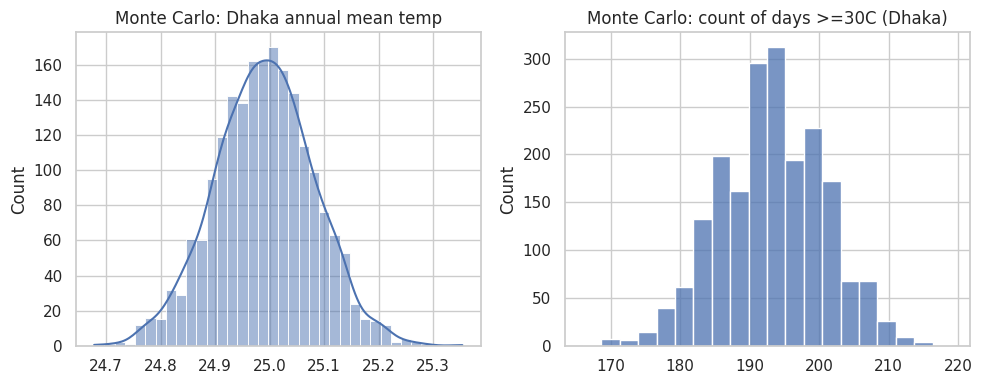

In [ ]:
# Monte Carlo: simulate N_future years by sampling daily noise, keeping seasonality and base
N_sim = 2000
future_mean_dhaka = np.zeros(N_sim)
future_extreme_counts = np.zeros(N_sim)     # days >= 30 C in future year for Dhaka

# Precompute deterministic seasonal component for Dhaka
j = cities.index('Dhaka')
seasonal_component = base_temp_by_city[j] + seasonal_amplitude[j] * np.sin(angles - np.pi/2)

for s in range(N_sim):
    # simulate one future year of noise-only draws
    noise = np.random.normal(0, noise_sd_by_city[j], n_days)
    sim_temps = seasonal_component + noise
    future_mean_dhaka[s] = sim_temps.mean()
    future_extreme_counts[s] = (sim_temps >= 30.0).sum()

# Summarize
print(f"Simulated MetroCity future-year mean temp: mean={future_mean_dhaka.mean():.3f}, sd={future_mean_dhaka.std():.3f}")
print(f"Probability (>=1 day with temp >=30C): {(future_extreme_counts >= 1).mean():.3%}")
print(f"Mean number of extreme days (>=30C): {future_extreme_counts.mean():.2f}")

# Plot distribution of simulated means
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(future_mean_dhaka, kde=True)
plt.title('Monte Carlo: Dhaka annual mean temp')

plt.subplot(1,2,2)
sns.histplot(future_extreme_counts, kde=False, bins=20)
plt.title('Monte Carlo: count of days >=30C (Dhaka)')
plt.tight_layout()
plt.show()
